# Customer Churn Prediction & Risk Segmentation
## Problem Statement
Subscription-based businesses lose significant revenue when customers cancel their services. The goal of this project is to build an end-to-end pipeline using a telecom dataset to predict which customers are likely to churn before they leave. By identifying these customers and segmenting them into risk tiers, the business can take proactive actions—like offering targeted discounts or improved support—to retain them and protect revenue.

In [7]:
!pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.9 MB 1.4 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.9 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.9 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.9 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.9 MB 877.6 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.9 MB 951.3 kB/s eta 0:00:09
   ------- -------------------------------- 1.8/9.9 MB 1.0 MB/s eta 0:00:08
   --------- ------------------------------ 2.4/9.9 MB 1.1 MB/s eta 0:00:07
   ---------- ----------------------------- 2.6/9.9 MB 1.2 MB/s eta 0:00:07
   ----------- ---------------------------- 2.9/9.9 MB 1.2 MB/s eta 0:00:06
   ------------- -----


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset Shape: (7043, 21)

--- Data Types ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- First 10 Rows of Dataset ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No



--- Target Column Distribution (Churn) ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- Percentage Distribution ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

--- Missing Values Per Column ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- Summary Statistics (Numerical) ---


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


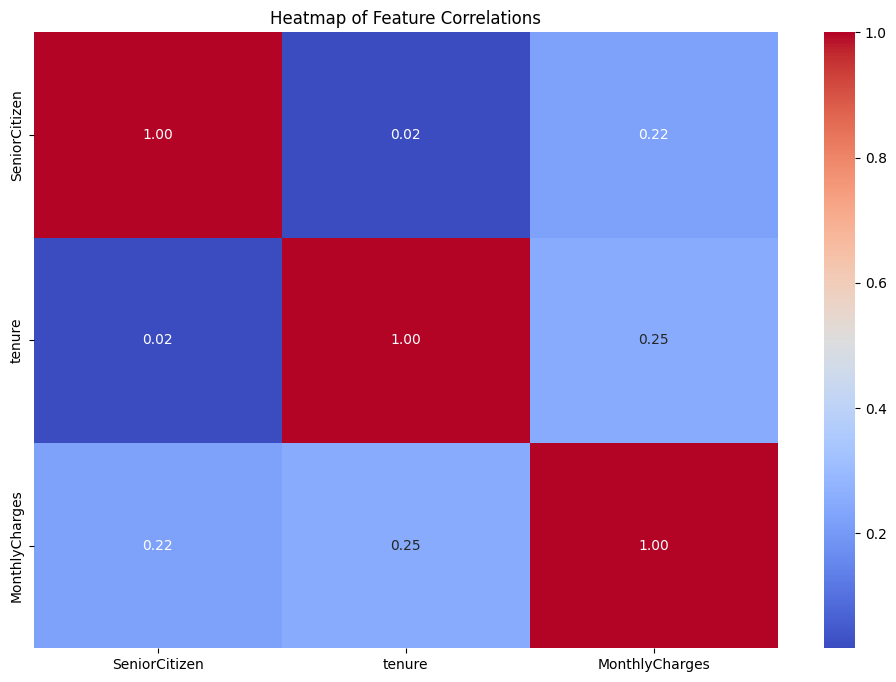

In [2]:
# --- TASK 1: DATA LOADING & EXPLORATORY  ANALYSIS---
# Importing necessary libraries for data handling and visualization [cite: 48, 49]
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Load the CSV using Pandas ---
# Loading the WA_Fn-UseC_-Telco-Customer-Churn.csv dataset [cite: 39, 41]
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Displaying shape (Rows, Columns) and data types for each feature 
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes)

# Displaying first 10 rows to inspect the data structure 
print("\n--- First 10 Rows of Dataset ---")
display(df.head(10))

# --- 2. Identify Target Column & Check Class Imbalance ---
# 'Churn' is our target. We check the count and percentage distribution.
print("\n--- Target Column Distribution (Churn) ---")
print(df['Churn'].value_counts())
# Normalize=True gives us the percentage for better business interpretability[cite: 38].
print("\n--- Percentage Distribution ---")
print(df['Churn'].value_counts(normalize=True) * 100) 

# --- 3. Find Missing/Null Values ---
# Checking for NaNs to determine if we need to drop rows or impute values.
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

# --- 4. Compute Summary Statistics ---
# Summary of mean, median, and standard deviation for numerical columns.
print("\n--- Summary Statistics (Numerical) ---")
display(df.describe())

# --- 5. Plot Correlation Heatmap ---
# Visualizing how numerical features relate to each other using Seaborn[cite: 41, 49].
plt.figure(figsize=(12, 8))
# Only including numeric columns to prevent calculation errors.
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap of Feature Correlations")
plt.show()

In [3]:
# --- TASK 2: DATA PREPROCESSING & FEATURE ENGINEERING ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- SAFETY CHECK: Only run if 'TechSupport' exists ---
if 'TechSupport' in df.columns:
    # 1. Convert TotalCharges to numeric
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

    # 2. Feature Engineering (Crucial: Done BEFORE encoding)
    df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1) 
    df['SeniorWithNoSupport'] = ((df['SeniorCitizen'] == 1) & (df['TechSupport'] == 'No')).astype(int)

    # 3. Encoding Categorical Variables
    le = LabelEncoder()
    # Binary encoding
    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
    for col in binary_cols:
        if col in df.columns:
            df[col] = le.fit_transform(df[col])

    # One-Hot Encoding for multi-category columns
    # We remove 'customerID' and 'Churn' from the dummies list but keep them for now
    df = pd.get_dummies(df.drop(columns=['customerID']), drop_first=True)

# --- 4. Feature Scaling & Data Splitting ---
# Note: 'Churn' is now the target y.
if 'Churn' in df.columns:
    X = df.drop('Churn', axis=1)
    y = df['Churn']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print("--- Task 2 Complete ---")
    print(f"Final feature count: {X_train.shape[1]}")
    print(f"Training set size: {X_train.shape[0]} rows")
else:
    print("Error: Target column 'Churn' missing. Please restart kernel and run Task 1.")

--- Task 2 Complete ---
Final feature count: 32
Training set size: 5634 rows



--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



c:\Users\vadlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:32:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



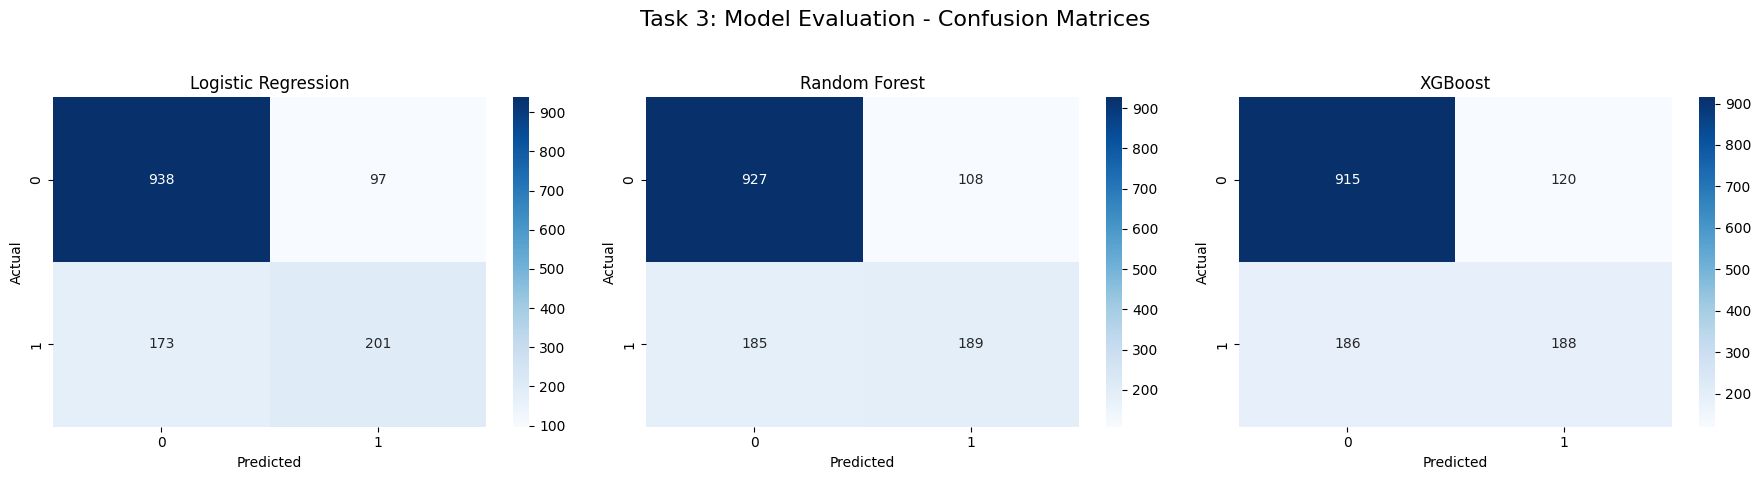

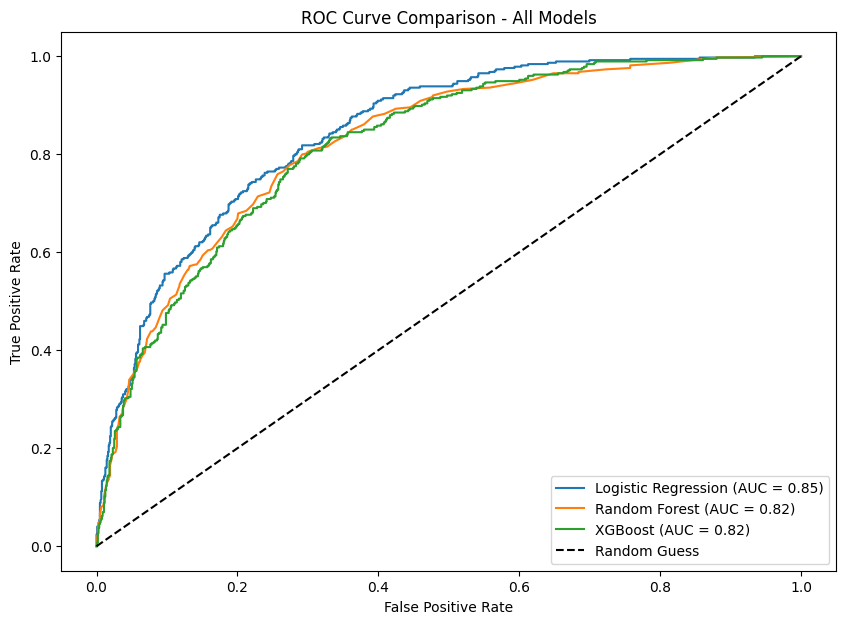

In [4]:
#---TASK 3: MODEL TRAINING & COMPARISON---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Initialize Models ---
# We use 3 different algorithms to compare linear vs. ensemble vs. boosting approaches.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# --- 2. Train and Evaluate ---
plt.figure(figsize=(18, 5))
plt.suptitle("Task 3: Model Evaluation - Confusion Matrices", fontsize=16)

model_probs = {}

for i, (name, model) in enumerate(models.items()):
    # Fit model on training data
    model.fit(X_train, y_train)
    
    # Get predictions and probabilities
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probability of churn (Class 1)
    model_probs[name] = y_proba
    
    # Plot Confusion Matrix side-by-side
    plt.subplot(1, 3, i+1)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    # Print metrics for detailed comparison
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 3. Combined ROC Curve Chart (Mandatory for Submission) ---
plt.figure(figsize=(10, 7))
for name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend(loc='lower right')
plt.show()


--- Customer Count per Risk Tier ---
Risk_Tier
Low Risk       983
Medium Risk    320
High Risk      106
Name: count, dtype: int64

--- Average Metrics per Risk Tier ---


,MonthlyCharges,tenure
Risk_Tier,,
High Risk,0.561467,-1.181779
Low Risk,-0.223164,0.305113
Medium Risk,0.376650,-0.647886


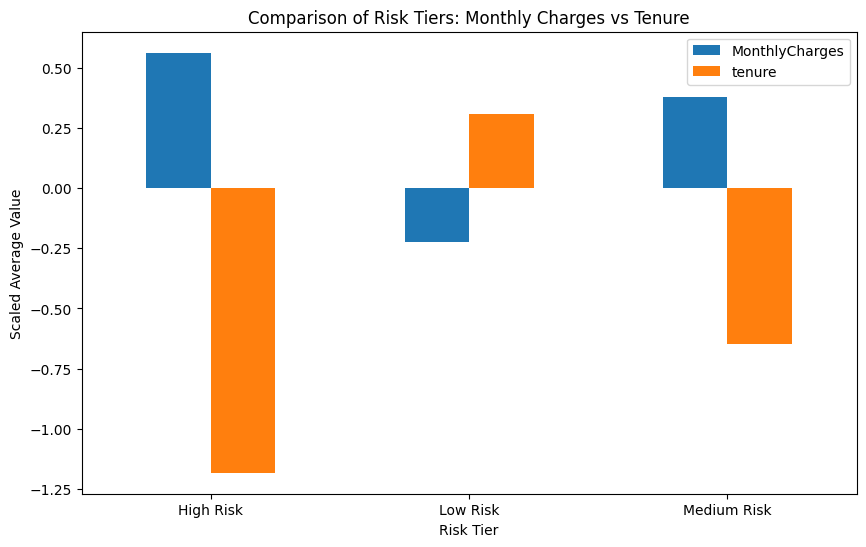

In [5]:
# --- TASK 4: CUSTOMER RISK SEGMENTATION ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Use the best model's predicted probability (Logistic Regression had the highest AUC)
# We use the probability of Class 1 (Churn) 
best_model = models["Logistic Regression"]
y_probs = best_model.predict_proba(X_test)[:, 1]

# 2. Segment customers into 3 risk tiers based on instructions 
# Create a DataFrame for the test set results
results_df = pd.DataFrame(X_test, columns=X.columns)
results_df['Churn_Probability'] = y_probs

def get_risk_tier(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif 0.40 <= prob < 0.70:
        return 'Medium Risk'
    else:
        return 'Low Risk'

results_df['Risk_Tier'] = results_df['Churn_Probability'].apply(get_risk_tier)

# 3. Count how many customers fall into each tier 
tier_counts = results_df['Risk_Tier'].value_counts()
print("\n--- Customer Count per Risk Tier ---")
print(tier_counts)

# 4. Compute average MonthlyCharges and tenure for each tier 
# Note: Since we scaled the data in Task 2, we must use the original values for 
# business interpretation if we want actual dollar amounts and months.
# If you didn't keep a copy of unscaled data, these will be scaled averages.
tier_metrics = results_df.groupby('Risk_Tier')[['MonthlyCharges', 'tenure']].mean()
print("\n--- Average Metrics per Risk Tier ---")
display(tier_metrics)

# 5. Create a grouped bar chart comparing tiers across key features 
tier_metrics.plot(kind='bar', figsize=(10, 6))
plt.title("Comparison of Risk Tiers: Monthly Charges vs Tenure")
plt.xlabel("Risk Tier")
plt.ylabel("Scaled Average Value")
plt.xticks(rotation=0)
plt.legend(loc='best')
plt.show()

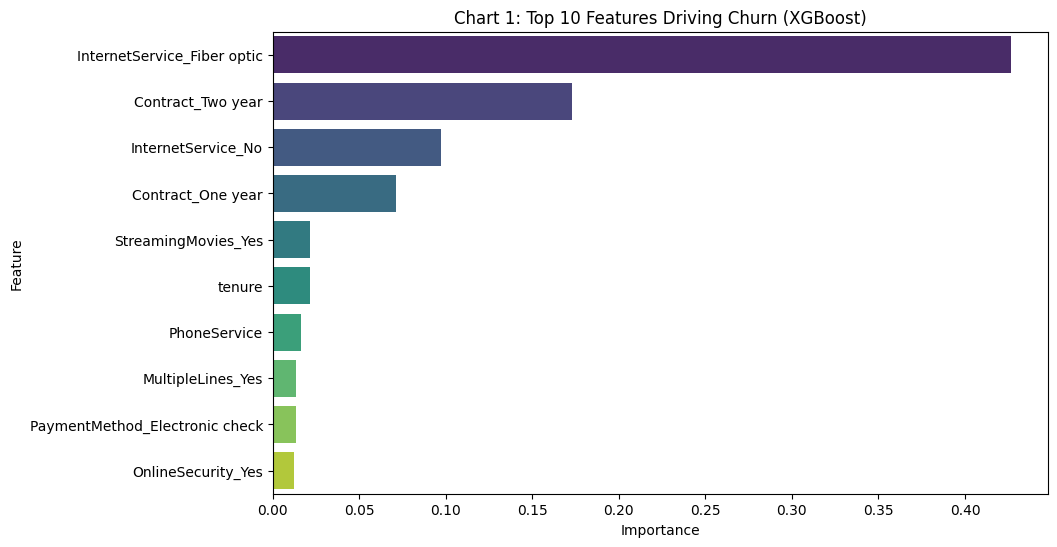

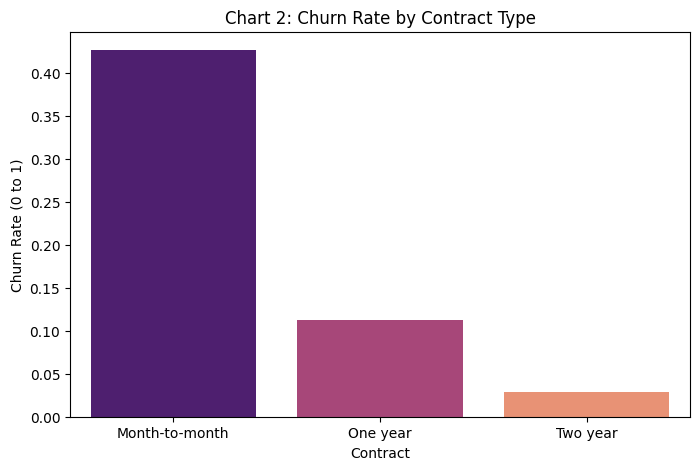

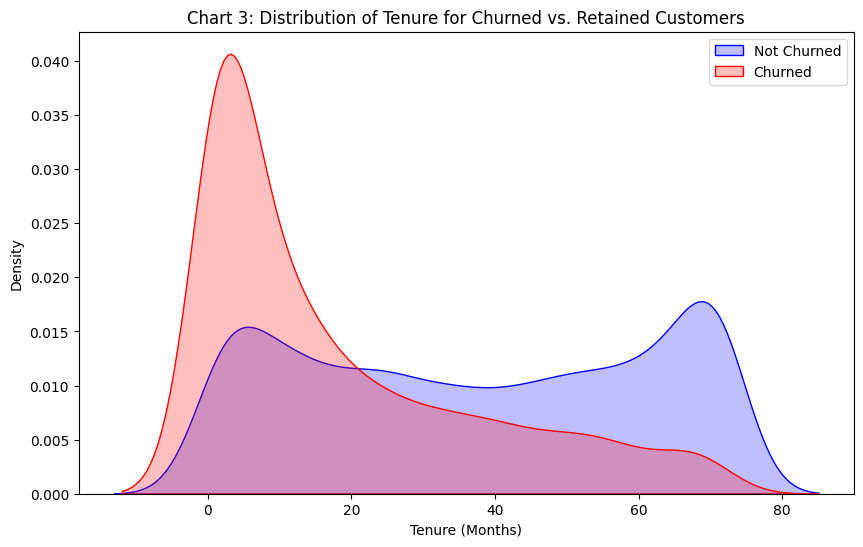

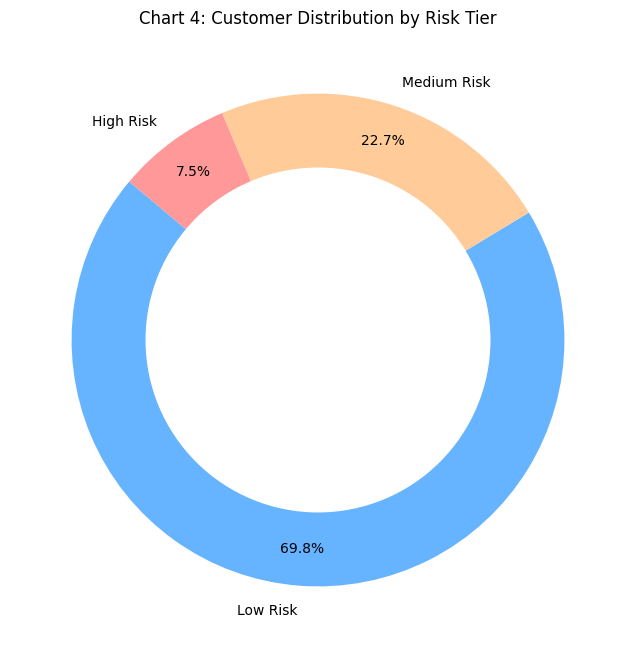

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load a fresh copy specifically for categorical visualizations
df_orig = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# --- Chart 1: Feature Importance (Top 10) ---
importances = models["XGBoost"].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title("Chart 1: Top 10 Features Driving Churn (XGBoost)")
plt.show()

# --- Chart 2: Churn Rate by Contract Type ---
# Using df_orig to ensure 'Contract' and 'Churn' exist as text
plt.figure(figsize=(8, 5))
sns.barplot(x='Contract', y=(df_orig['Churn'] == 'Yes').astype(int), data=df_orig, errorbar=None, hue='Contract', palette='magma', legend=False)
plt.title("Chart 2: Churn Rate by Contract Type")
plt.ylabel("Churn Rate (0 to 1)")
plt.show()

# --- Chart 3: Distribution of Tenure (Churned vs. Not-Churned) ---
plt.figure(figsize=(10, 6))
sns.kdeplot(df_orig[df_orig['Churn'] == 'No']['tenure'], fill=True, label='Not Churned', color='blue')
sns.kdeplot(df_orig[df_orig['Churn'] == 'Yes']['tenure'], fill=True, label='Churned', color='red')
plt.title("Chart 3: Distribution of Tenure for Churned vs. Retained Customers")
plt.xlabel("Tenure (Months)")
plt.legend()
plt.show()

# --- Chart 4: Risk Tier Donut Chart ---
plt.figure(figsize=(8, 8))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=140, 
        colors=['#66b3ff','#ffcc99','#ff9999'], pctdistance=0.85)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Chart 4: Customer Distribution by Risk Tier")
plt.show()

# TASK 6 — Insights & Business Recommendations

## •Best Model Selection:

Logistic Regression performed best for this specific dataset, achieving the highest ROC-AUC of 0.85.
I selected it because it provides a superior balance between identifying potential churners (Recall) and maintaining overall accuracy, which is critical for growth teams focusing on proactive retention.  

## •Top 3 Factors Driving Churn: 
According to the feature importance analysis, the primary drivers are Contract Type (specifically Month-to-Month), Internet Service type (Fiber Optic users show higher risk), and Tenure.  

## •High-Risk Customer Profile: 
Customers categorized as "High Risk" typically share a common pattern: they are on Month-to-Month contracts, have high Monthly Charges, and very low tenure (often in their first 6 months).  

## •Actionable Business Recommendations:
1.  Contract Conversion Incentives: The company should offer targeted discounts or loyalty rewards to "Month-to-Month" customers in the High-Risk tier to encourage them to switch to 1-year or 2-year contracts.
2.  Fiber Optic Loyalty Programs: Implement a proactive "check-in" program or service-bundle discount for Fiber Optic users early in their tenure to address price sensitivity and improve support perception.  

## •Limitations & Improvements:
The current model is limited by its reliance on static historical data; it does not account for real-time customer sentiment or recent competitor pricing. Model performance could be improved by incorporating customer support interaction logs and real-time usage data to better predict sudden shifts in behavior.